In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Titanic dataset

In [ ]:
# Load the Titanic dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Part I: Frequency Analysis

### Absolute Frequency

In [9]:
df["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

### Relative Frequency

In [10]:
df["class"].value_counts(normalize=True)

class
Third     0.551066
First     0.242424
Second    0.206510
Name: proportion, dtype: float64

### Relative Frequency in Percentage

In [11]:
df["class"].value_counts(normalize=True) * 100

class
Third     55.106622
First     24.242424
Second    20.650954
Name: proportion, dtype: float64

### Cumulative Frequency

In [12]:
df["class"].value_counts().cumsum()

class
Third     491
First     707
Second    891
Name: count, dtype: int64

### Create a Proper Frequency Table

In [13]:
absolute = df["class"].value_counts().sort_index()

relative = (
    df["class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

cumulative = absolute.cumsum()

frequency_table = pd.DataFrame({
    "Absolute Frequency": absolute,
    "Relative Frequency (%)": relative,
    "Cumulative Frequency": cumulative
})

frequency_table

,Absolute Frequency,Relative Frequency (%),Cumulative Frequency
class,,,
First,216,24.24,216
Second,184,20.65,400
Third,491,55.11,891


# Part II: Probability Analysis

### Create the Contingency Table

In [14]:
pd.crosstab(df["sex"], df["survived"])

survived,0,1
sex,,
female,81,233
male,468,109


### Store the Contingency Table

In [15]:
contingency = pd.crosstab(df["sex"], df["survived"])

contingency

survived,0,1
sex,,
female,81,233
male,468,109


### Joint Probability

In [16]:
joint_probability = contingency / len(df)

joint_probability

survived,0,1
sex,,
female,0.090909,0.261504
male,0.525253,0.122334


### Marginal Probability

In [17]:
df["sex"].value_counts(normalize=True)

sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [18]:
df["survived"].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Conditional Probability

In [19]:
pd.crosstab(
    df["sex"],
    df["survived"],
    normalize="index"
)

survived,0,1
sex,,
female,0.257962,0.742038
male,0.811092,0.188908


# Part III: Correlation Analysis

### Select Required Columns

In [20]:
df[["age", "fare"]].head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


### Check Missing Values

In [21]:
df[["age","fare"]].isnull().sum()

age     177
fare      0
dtype: int64

### Remove Missing Values

In [22]:
corr_data = df[["age","fare"]].dropna()

corr_data.head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


### Calculate Pearson Correlation

In [23]:
corr_data.corr()

,age,fare
age,1.000000,0.096067
fare,0.096067,1.000000


### Store the Correlation Matrix

In [24]:
correlation = corr_data.corr()

correlation

,age,fare
age,1.000000,0.096067
fare,0.096067,1.000000


### Draw the Heatmap

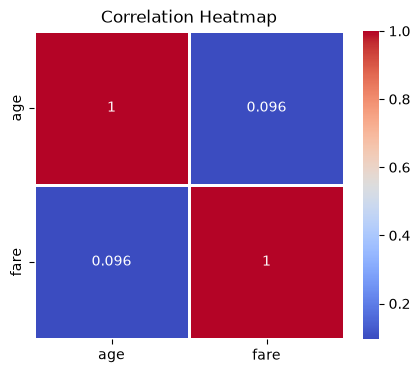

In [25]:
plt.figure(figsize=(5,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

### Scatter Plot

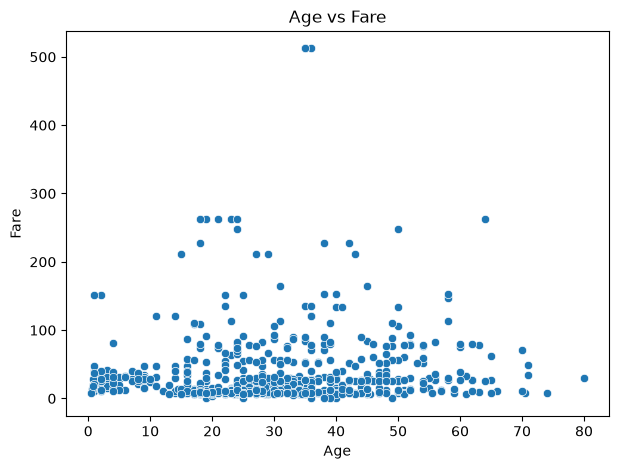

In [26]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=corr_data,
    x="age",
    y="fare"
)

plt.title("Age vs Fare")

plt.xlabel("Age")

plt.ylabel("Fare")

plt.show()

### Stacked Bar Chart

In [27]:
survival_class = pd.crosstab(df["class"], df["survived"])

survival_class

survived,0,1
class,,
First,80,136
Second,97,87
Third,372,119


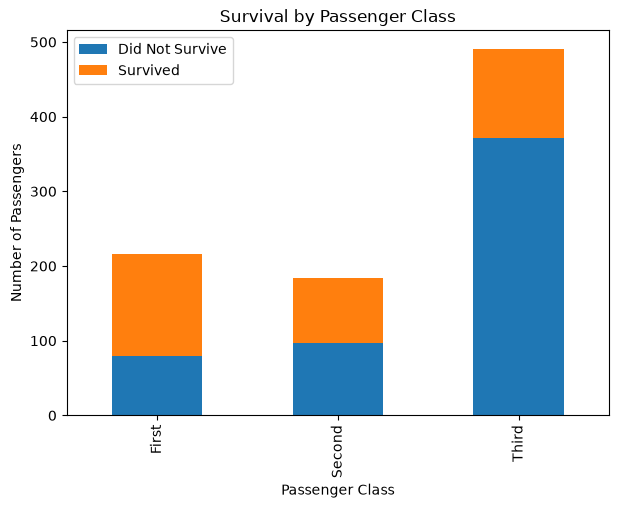

In [28]:
survival_class.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Survival by Passenger Class")

plt.xlabel("Passenger Class")

plt.ylabel("Number of Passengers")

plt.legend(["Did Not Survive", "Survived"])

plt.show()

# Assignment Questions


### Frequency table for Embarked

In [30]:
df["embarked"].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

### Probability that a passenger survived

In [31]:
df["survived"].mean()

np.float64(0.3838383838383838)

### Pearson Correlation

In [32]:
correlation.loc["age", "fare"]

np.float64(0.09606669176903912)